In [1]:
import os
import time
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torch.optim.lr_scheduler import ReduceLROnPlateau
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score
from tqdm import tqdm

In [2]:
# Define parameters
CSV_FILE = "C:/Users/Azucar/Desktop/Master Thesis/Code/training_labels_Qsigma_EU_6perceptions.csv"
IMAGE_FOLDER = "C:/Users/Azucar/Desktop/Master Thesis/Code/pp2.0_images/"
BATCH_SIZE = 32 # Number of images processed before updating weights
NUM_EPOCH = 25 # Number of full passes through the dataset
LR = 3e-5 # How much weights change per update
IMG_SIZE = 256 # Resize target before cropping
CROP_SIZE = 224 # Input image resolution designed for ResNet50 is ImageNet standard, 224*224*3
MIXUP_ALPHA = 0.2 # Mixup interpolation strength
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu") # Select GPU over CPU to speed up
WEIGHTS_FOLDER = "weights" 
os.makedirs(WEIGHTS_FOLDER, exist_ok=True) # Create folder to store trained models

In [3]:
# Load CSV file and filter images
start_time = time.time() # Start the timer
df = pd.read_csv(CSV_FILE) 

# Check which images are actually present
df["img_path"] = df["image_id"].apply(lambda x: os.path.join(IMAGE_FOLDER, x + ".jpg"))
df = df[df["img_path"].apply(os.path.exists)].reset_index(drop=True)

print(f"Total images after filtering missing: {len(df)}")

Total images after filtering missing: 42399


In [5]:
def split_perception(df, perception):
    sub_df = df[df["perception"] == perception].copy()
    sub_df = sub_df.drop_duplicates(subset=["image_id", "perception"]) # Remove duplicated rows
    image_df = sub_df[["image_id", "label"]].drop_duplicates() # Create image-level dataframe
    train_ids, val_ids = train_test_split(  # Stratified image-level split 
        image_df["image_id"],
        test_size=1/6,
        random_state=42,
        stratify=image_df["label"])
    train_df = sub_df[sub_df["image_id"].isin(train_ids)]
    val_df = sub_df[sub_df["image_id"].isin(val_ids)]
    
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

In [6]:
# Define how PyTorch load the images
class PlacePulseDataset(Dataset):
    def __init__(self, dataframe, image_folder, transform=None, return_id=False):
        self.data = dataframe.reset_index(drop=True) # Reset row index
        self.image_folder = image_folder # Store image folder
        self.transform = transform # Store augmentation settings
        self.return_id = return_id
        
    def __len__(self): 
        return len(self.data) # Tell PyTorch how many smaples exist
    
    def __getitem__(self, idx):
        row = self.data.iloc[idx] # Fetch row info from .csv file
        img_path = os.path.join(self.image_folder, row["image_id"] + ".jpg") # Build image filename
        image = Image.open(img_path).convert("RGB") # Load image using PIL with 3 channels
        if self.transform:
            image = self.transform(image) # Apply resize, augmentation, normalization
        label = torch.tensor(row["label"], dtype=torch.long) # Convert label into tensor
        
        if self.return_id:
            return image, label, row["image_id"]
        else: 
            return image, label # Return output format required by PyTorch

In [7]:
# Transform images
train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE), # Resize all images into 224*224 required by ResNet
    transforms.RandomResizedCrop(CROP_SIZE, scale=(0.9, 1.0)),
    transforms.RandomHorizontalFlip(), # Mirror images randomly to increate dataset diversity
    transforms.RandomRotation(degrees=10), # Add random rotation
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.03), # Randomize brightness to simulate different weather and light conditions
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)), # Small spatial shift
    # transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)), # Simulate focus variation
    transforms.ToTensor(), # Convert from [0,255] pixels to [0,1] tensor and rearrange image format into (channel, height, width)
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Match the data statitics of ImageNet, which was used to pretain weights for ResNet50
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.08), ratio=(0.3, 3.3)) # Occlusion simulation, randomly cuts out a rectangular patch in the image, 25% chance to apply, erase 2% to 8% of image
])

val_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.CenterCrop(CROP_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [8]:
# Prepare for the unfreezing strategy
def set_trainable_layers(model, trainable_layers):
    for name, param in model.named_parameters():
        param.requires_grad = False
        for layer in trainable_layers:
            if layer in name:
                param.requires_grad = True

# Define the training function
def train_model(perception, pretrained_weights=None):
    start_time_total = time.time() # Start a timer to measure total training duration
    print(f"\n===== Training perception: {perception.upper()} =====")
    
    # Call the data splitting function which is stratified by label and has balanced train/validation dataset
    train_df, val_df = split_perception(df, perception)

    print(f"Training samples: {len(train_df)}, Validation samples: {len(val_df)}")
    print(f"Unique train images: {train_df['image_id'].nunique()}")
    print(f"Unique val images: {val_df['image_id'].nunique()}")

    print("Train label distribution:")
    print(train_df["label"].value_counts(normalize=True))
    print("Val label distribution:")
    print(val_df["label"].value_counts(normalize=True))
    
    # Build training dataset with rows where perception matches, with images loaded from the folder, with augmentations applied
    train_dataset = PlacePulseDataset(train_df, IMAGE_FOLDER, transform=train_transform)
    # Build validation dataset with no augmentation but only normalization
    val_dataset = PlacePulseDataset(val_df, IMAGE_FOLDER, transform=val_transform)
    
    # Create batch loader to load images in group of 32 and shuffle order for each epoch, without multiprocessing
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle= False, num_workers=0)
    
    # Load ResNet50
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1) # Initialize with weights pretrained by Imagenet            
    model.fc = nn.Sequential(
        nn.Linear(model.fc.in_features, 256),
        nn.BatchNorm1d(256),
        nn.ReLU(),
        nn.Dropout(0.5),  
        nn.Linear(256, 2))
    model = model.to(DEVICE)
         
    # Phase 1: Freeze backbone, train classifier head only
    set_trainable_layers(model, ["fc"])
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Define the loss function using cross-entropy loss
    optimizer = optim.AdamW(    # Define how weights update, using Adam for adaptive learning rate and fast convergence
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR,
        weight_decay=5e-4)
    
    # Scheduler for reducing LR if validation loss stagnates
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2)
    
    # Track history
    # Create empty lists to store metrics for each epoch, which will be used later to plot learning curves and detect over/underfitting
    train_losses, val_losses = [], [] 
    train_accs, val_accs = [], []
    
    # Store the best validation accuracy so far
    best_val_loss = float("inf") # Store the best validation loss so far
    epochs_no_improve = 0 # Early stopping
    patience = 5 # Stop training if val_acc doesn't improve for 5 epochs
 
    # Loop over epochs
    for epoch in range(NUM_EPOCH):
        epoch_start = time.time() # Measure how long each epoch takes
        print(f"\n Epoch {epoch+1}/{NUM_EPOCH} for {perception}")
        
        # Start Training & Initialize counters
        model.train()
        running_loss = 0.0 # sum of loss 
        correct = 0 # number of correct predictions
        total = 0 # total samples
        
        # Unfreeze layer4
        if epoch == 5:
            print("\nStage 2: Unfreeze layer4")
            set_trainable_layers(model, ["fc", "layer4"])
            optimizer = optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=1e-5,
                weight_decay=5e-4)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=2)

        # Unfreeze layer3
        if epoch == 12:
            print("\nStage 3: Unfreeze layer3")
            set_trainable_layers(model, ["fc", "layer3", "layer4"])
            optimizer = optim.AdamW(
                filter(lambda p: p.requires_grad, model.parameters()),
                lr=5e-6,
                weight_decay=5e-4)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=2)

        # Unfreeze layer2
       # if epoch == 18:
       #     print("\nStage 4: Unfreeze layer2")
       #     set_trainable_layers(model, ["fc", "layer2", "layer3", "layer4"])
       #     optimizer = optim.AdamW(
       #         filter(lambda p: p.requires_grad, model.parameters()),
       #         lr=5e-6,
       #         weight_decay=5e-4)
       #     scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
       #         optimizer, mode='min', factor=0.5, patience=2)
            
    
        # Loop over batches instead of all images at once
        # Iterate through each batch of images and labels & Show a training progress bar
        for images, labels in tqdm(train_loader, desc="Training", ncols=80): 
            images = images.to(DEVICE) # Use GPU to speed up
            labels = labels.to(DEVICE) 
            optimizer.zero_grad() # Clear gradients from previous batch before computing new ones
            outputs = model(images) # Use ResNet50 to process images and result in logits
            loss = criterion(outputs, labels) # Compute cross-entropy loss
            loss.backward() # Backpropogation to compute gradients of all weights
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # Gradient clipping to stabilize fine-tuning
            optimizer.step() # Update model weights using the defined optimizer
            running_loss += loss.item() * images.size(0) # Multiply batch loss by batch size to get total loss
            preds = torch.argmax(outputs, dim=1) # Select class (0/1) with the highest logit
            correct += (preds == labels).sum().item() # Count total correct predictions
            total += labels.size(0) # Count total number of processed samples 
        
        # Compute average training loss and training accuracy
        train_loss = running_loss / total
        train_acc = correct / total
        
        # Start validation & Reset counters
        model.eval() # Disable dropout and freeze BatchNorm statistics
        correct = 0
        total = 0
        val_loss_sum = 0.0
        
        # Disable gradient computation to speed up inference and ensure no weight updates here
        # Same forward pass as training but no backward pass
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc="Validation", ncols=80):
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
                outputs = model(images)
                # Loss computation
                loss = criterion(outputs, labels)
                val_loss_sum += loss.item() * images.size(0)
                # Prediction
                preds = torch.argmax(outputs, dim=1)
                # Accuracy counting
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        
        # Compute average validation loss and validation accuracy
        val_loss = val_loss_sum / total
        val_acc = correct / total
        
        # Update scheduler
        scheduler.step(val_loss)
        print(f"Epoch {epoch+1}, LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Store history for plotting
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        print(f"Epoch {epoch+1} finished in {time.time() - epoch_start:.2f}s | "
              f"Train loss: {train_loss:.4f}, Train accuracy: {train_acc:.4f} | "
              f"Val loss: {val_loss:.4f}, Val accuracy: {val_acc:.4f}")
        
        # Save model checkpoints after each epoch
        checkpoint_path = os.path.join(WEIGHTS_FOLDER, f"{perception}_epoch{epoch+1}.pt")
        torch.save(model.state_dict(), checkpoint_path)
        
        # Save best model and update no improvement counter
     #   if val_acc > best_val_acc:
     #       best_val_acc = val_acc
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc = val_acc
            epochs_no_improve = 0
            torch.save(model.state_dict(), os.path.join(WEIGHTS_FOLDER, f"{perception}_best.pt"))
        else:
            epochs_no_improve += 1
            print(f"No improvement for {epochs_no_improve} epoch(s)")
            
        # Trigger early stopping when needed
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break
    
    # Load the best model for printing confusion matrix
    print("\nLoading best model for final evaluation...")
    model.load_state_dict(torch.load(os.path.join(WEIGHTS_FOLDER, f"{perception}_best.pt")))
    model.eval()

    # Compute confusion matrix
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    print("Final Confusion Matrix:")
    print(cm)
    
    # Plot confusion matrix
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"{perception.upper()} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()
            
    # Plot training vs validation loss/accuracy
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.legend()
    plt.title(f"{perception} Loss")

    plt.subplot(1,2,2)
    plt.plot(train_accs, label="Train Acc")
    plt.plot(val_accs, label="Val Acc")
    plt.legend()
    plt.title(f"{perception} Accuracy")

    plt.show()
            
    print(f"Finished training {perception}, best val accuracy: {best_val_acc:.4f}"
          f"in {time.time() - start_time_total:.2f}s")
    return os.path.join(WEIGHTS_FOLDER, f"{perception}_best.pt")


===== Training perception: DEPRESSION =====
Training samples: 3077, Validation samples: 616
Unique train images: 3077
Unique val images: 616
Train label distribution:
label
1    0.538512
0    0.461488
Name: proportion, dtype: float64
Val label distribution:
label
1    0.538961
0    0.461039
Name: proportion, dtype: float64

 Epoch 1/25 for depression


Validation: 100%|███████████████████████████████| 20/20 [00:03<00:00,  6.51it/s]


Epoch 1, LR: 0.000030
Epoch 1 finished in 48.50s | Train loss: 0.7151, Train accuracy: 0.5837 | Val loss: 0.6166, Val accuracy: 0.6769

 Epoch 2/25 for depression


Validation: 100%|███████████████████████████████| 20/20 [00:03<00:00,  6.50it/s]


Epoch 2, LR: 0.000030
Epoch 2 finished in 34.92s | Train loss: 0.6356, Train accuracy: 0.6646 | Val loss: 0.6046, Val accuracy: 0.7094

 Epoch 3/25 for depression


...

Epoch 12, LR: 0.000005
Epoch 12 finished in 35.50s | Train loss: 0.5285, Train accuracy: 0.7663 | Val loss: 0.5822, Val accuracy: 0.7338
No improvement for 3 epoch(s)

 Epoch 13/25 for depression

Stage 3: Unfreeze layer3


Validation: 100%|███████████████████████████████| 20/20 [00:02<00:00,  6.97it/s]


Epoch 13, LR: 0.000005
Epoch 13 finished in 36.96s | Train loss: 0.5090, Train accuracy: 0.7855 | Val loss: 0.5770, Val accuracy: 0.7321
No improvement for 4 epoch(s)

 Epoch 14/25 for depression


Validation: 100%|███████████████████████████████| 20/20 [00:02<00:00,  6.72it/s]
C:\Users\Azucar\AppData\Local\Temp\ipykernel_28140\1785686766.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

Epoch 14, LR: 0.000005
Epoch 14 finished in 36.98s | Train loss: 0.5028, Train accuracy: 0.7953 | Val loss: 0.5811, Val accuracy: 0.7386
No improvement for 5 epoch(s)
Early stopping triggered

Loading best model for final evaluation...
Final Confusion Matrix:
[[193  91]
 [ 73 259]]


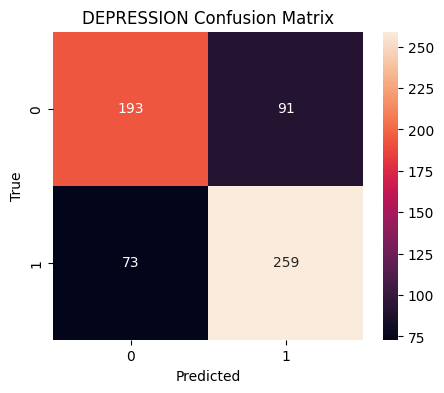

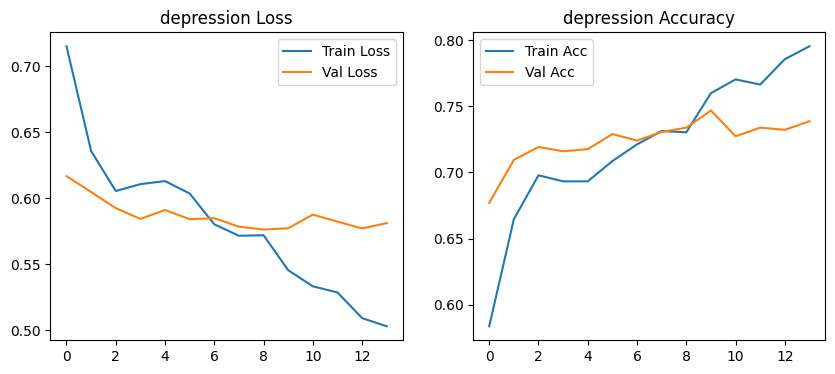

Finished training depression, best val accuracy: 0.7338in 521.10s


In [22]:
# Train ResNet50 for depression
depression_weights = train_model("depression")


===== Training perception: AESTHETIC =====

===== Training perception: AESTHETIC =====
Training samples: 7038, Validation samples: 1408
Unique train images: 7038
Unique val images: 1408
Train label distribution:
label
1    0.565928
0    0.434072
Name: proportion, dtype: float64
Val label distribution:
label
1    0.566051
0    0.433949
Name: proportion, dtype: float64

 Epoch 1/25 for aesthetic


Validation: 100%|███████████████████████████████| 44/44 [00:14<00:00,  3.04it/s]


Epoch 1, LR: 0.000030
Epoch 1 finished in 125.39s | Train loss: 0.6403, Train accuracy: 0.6613 | Val loss: 0.5595, Val accuracy: 0.7472

 Epoch 2/25 for aesthetic


Validation: 100%|███████████████████████████████| 44/44 [00:07<00:00,  6.20it/s]


Epoch 2, LR: 0.000030
Epoch 2 finished in 83.41s | Train loss: 0.6024, Train accuracy: 0.7103 | Val loss: 0.5548, Val accuracy: 0.7429

 Epoch 3/25 for aesthetic


...

Epoch 11, LR: 0.000005
Epoch 11 finished in 79.17s | Train loss: 0.5144, Train accuracy: 0.7850 | Val loss: 0.5464, Val accuracy: 0.7649
No improvement for 3 epoch(s)

 Epoch 12/25 for aesthetic


Validation: 100%|███████████████████████████████| 44/44 [00:06<00:00,  6.61it/s]


Epoch 12, LR: 0.000005
Epoch 12 finished in 81.58s | Train loss: 0.5001, Train accuracy: 0.7978 | Val loss: 0.5461, Val accuracy: 0.7656
No improvement for 4 epoch(s)

 Epoch 13/25 for aesthetic

Stage 3: Unfreeze layer3


Validation: 100%|███████████████████████████████| 44/44 [00:06<00:00,  6.54it/s]
C:\Users\Azucar\AppData\Local\Temp\ipykernel_28140\1785686766.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

Epoch 13, LR: 0.000005
Epoch 13 finished in 83.93s | Train loss: 0.4961, Train accuracy: 0.8016 | Val loss: 0.5478, Val accuracy: 0.7678
No improvement for 5 epoch(s)
Early stopping triggered

Loading best model for final evaluation...
Final Confusion Matrix:
[[448 163]
 [165 632]]


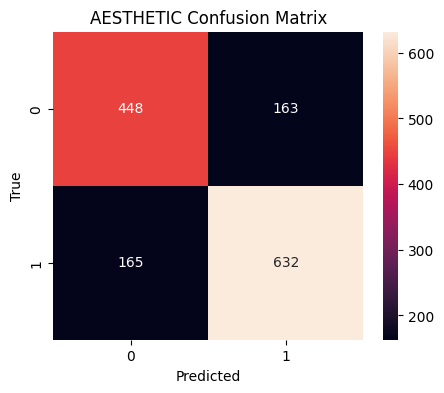

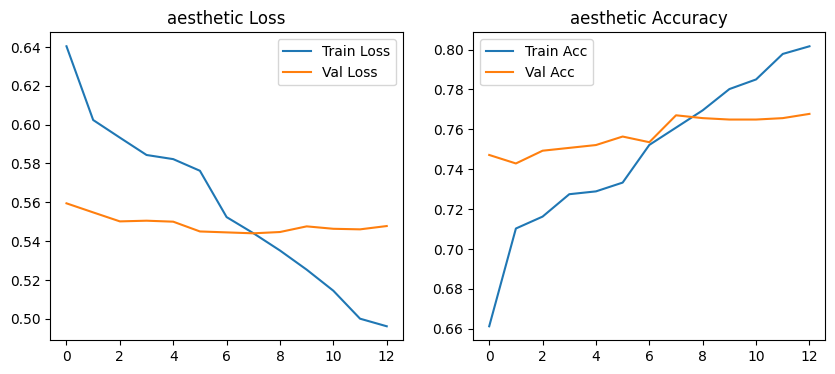

Finished training aesthetic, best val accuracy: 0.7670in 1113.80s
Finished aesthetic training in 18.56 minutes

===== Training perception: SAFETY =====

===== Training perception: SAFETY =====
Training samples: 7877, Validation samples: 1576
Unique train images: 7877
Unique val images: 1576
Train label distribution:
label
1    0.535356
0    0.464644
Name: proportion, dtype: float64
Val label distribution:
label
1    0.535533
0    0.464467
Name: proportion, dtype: float64

 Epoch 1/25 for safety


Validation: 100%|███████████████████████████████| 50/50 [00:14<00:00,  3.40it/s]


Epoch 1, LR: 0.000030
Epoch 1 finished in 130.08s | Train loss: 0.6583, Train accuracy: 0.6391 | Val loss: 0.5808, Val accuracy: 0.7297

 Epoch 2/25 for safety


Validation: 100%|███████████████████████████████| 50/50 [00:07<00:00,  6.57it/s]


Epoch 2, LR: 0.000030
Epoch 2 finished in 87.06s | Train loss: 0.6179, Train accuracy: 0.6961 | Val loss: 0.5736, Val accuracy: 0.7278

 Epoch 3/25 for safety


...

Epoch 16, LR: 0.000003
Epoch 16 finished in 93.35s | Train loss: 0.4799, Train accuracy: 0.8141 | Val loss: 0.5482, Val accuracy: 0.7665
No improvement for 3 epoch(s)

 Epoch 17/25 for safety


Validation: 100%|███████████████████████████████| 50/50 [00:07<00:00,  6.49it/s]


Epoch 17, LR: 0.000003
Epoch 17 finished in 96.74s | Train loss: 0.4633, Train accuracy: 0.8279 | Val loss: 0.5489, Val accuracy: 0.7665
No improvement for 4 epoch(s)

 Epoch 18/25 for safety


Validation: 100%|███████████████████████████████| 50/50 [00:07<00:00,  6.78it/s]
C:\Users\Azucar\AppData\Local\Temp\ipykernel_28140\1785686766.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

Epoch 18, LR: 0.000003
Epoch 18 finished in 97.39s | Train loss: 0.4618, Train accuracy: 0.8279 | Val loss: 0.5443, Val accuracy: 0.7709
No improvement for 5 epoch(s)
Early stopping triggered

Loading best model for final evaluation...
Final Confusion Matrix:
[[547 185]
 [171 673]]


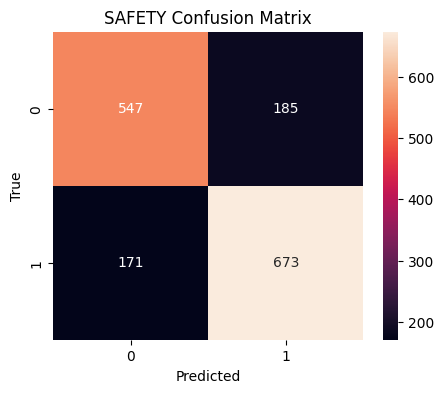

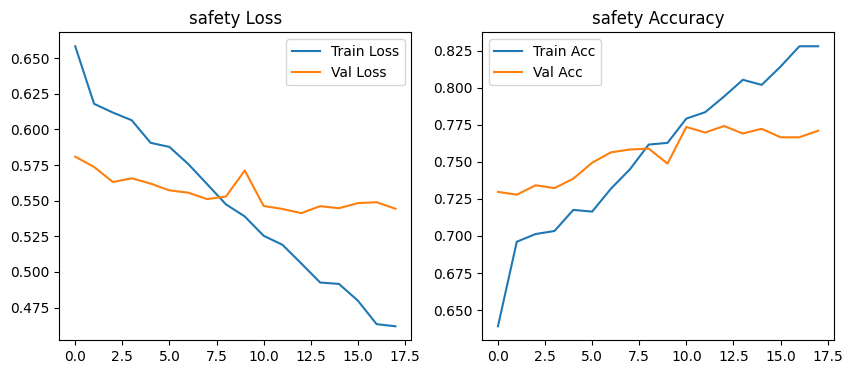

Finished training safety, best val accuracy: 0.7741in 1731.98s
Finished safety training in 28.87 minutes

===== Training perception: VITALITY =====

===== Training perception: VITALITY =====
Training samples: 9800, Validation samples: 1960
Unique train images: 9800
Unique val images: 1960
Train label distribution:
label
1    0.509184
0    0.490816
Name: proportion, dtype: float64
Val label distribution:
label
1    0.509184
0    0.490816
Name: proportion, dtype: float64

 Epoch 1/25 for vitality


Validation: 100%|███████████████████████████████| 62/62 [00:16<00:00,  3.81it/s]


Epoch 1, LR: 0.000030
Epoch 1 finished in 153.45s | Train loss: 0.6039, Train accuracy: 0.7033 | Val loss: 0.5482, Val accuracy: 0.7592

 Epoch 2/25 for vitality


Validation: 100%|███████████████████████████████| 62/62 [00:09<00:00,  6.66it/s]


Epoch 2, LR: 0.000030
Epoch 2 finished in 112.43s | Train loss: 0.5718, Train accuracy: 0.7355 | Val loss: 0.5403, Val accuracy: 0.7571

 Epoch 3/25 for vitality


...

Epoch 10, LR: 0.000005
Epoch 10 finished in 119.23s | Train loss: 0.4972, Train accuracy: 0.7962 | Val loss: 0.5299, Val accuracy: 0.7704
No improvement for 3 epoch(s)

 Epoch 11/25 for vitality


Validation: 100%|███████████████████████████████| 62/62 [00:09<00:00,  6.80it/s]


Epoch 11, LR: 0.000005
Epoch 11 finished in 112.87s | Train loss: 0.4940, Train accuracy: 0.8035 | Val loss: 0.5245, Val accuracy: 0.7791
No improvement for 4 epoch(s)

 Epoch 12/25 for vitality


Validation: 100%|███████████████████████████████| 62/62 [00:09<00:00,  6.53it/s]
C:\Users\Azucar\AppData\Local\Temp\ipykernel_28140\1785686766.py:195: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this 

Epoch 12, LR: 0.000005
Epoch 12 finished in 113.57s | Train loss: 0.4836, Train accuracy: 0.8090 | Val loss: 0.5342, Val accuracy: 0.7719
No improvement for 5 epoch(s)
Early stopping triggered

Loading best model for final evaluation...
Final Confusion Matrix:
[[734 228]
 [200 798]]


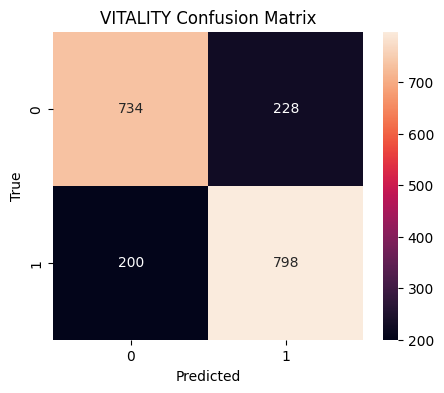

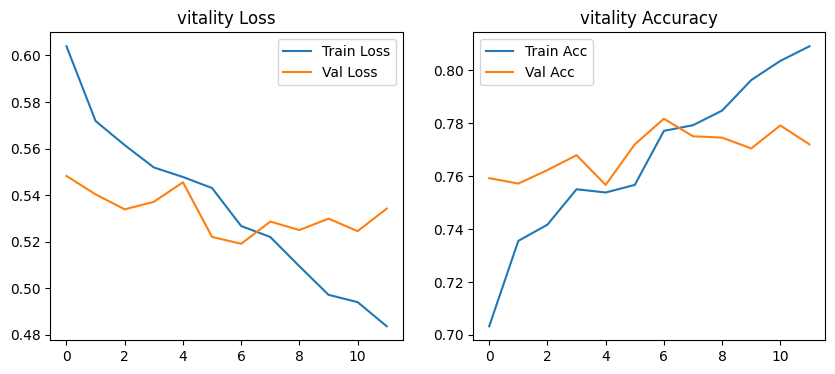

Finished training vitality, best val accuracy: 0.7816in 1417.66s
Finished vitality training in 23.63 minutes

All perceptions trained.


In [23]:
# Train ResNet50 for each perception
# PyTorch updates weights automatically using backpropogation
for perception in ["aesthetic", "boringness", "safety", "vitality", "wealth"]:
    print(f"\n===== Training perception: {perception.upper()} =====")
    start_time = time.time() # Start timer for this perception
    train_model(perception)
    elapsed = time.time() - start_time
    print(f"Finished {perception} training in {elapsed/60:.2f} minutes")
print("\nAll perceptions trained.")